Random Forest Classifier Without Removal

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])

df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

# 3. Select numerical features and target
features = ['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 6. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# 8. Predict and evaluate
y_pred = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.5676470588235294
Confusion Matrix:
 [[ 0  1  4  0  0  0  0  4  0  0  0]
 [ 0  5 10  0  1  0  0  7  1  0  3]
 [ 0  3 93  0  1  0  4  5  4  0 16]
 [ 0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0]
 [ 0  0  1  0  0  1  0  0  0  0  0]
 [ 0  1  5  0  0  0  2  0  0  0  4]
 [ 0  5  4  0  0  0  0 12  0  0  3]
 [ 0  0 10  0  0  0  0  1 64  0  3]
 [ 0  0  1  0  0  0  0  0  0  2  0]
 [ 1  0 39  0  0  0  2  1  0  0 13]]
Classification Report:
                  precision    recall  f1-score   support

     Carb Shale       0.00      0.00      0.00         9
     Grey Shale       0.33      0.19      0.24        27
Sandstone (SST)       0.55      0.74      0.63       126
          Shale       0.00      0.00      0.00         2
      Siltstone       0.33      1.00      0.50         1
       Top Soil       1.00      0.50      0.67         2
            alt       0.25      0.17      0.20        12
           coal       0.40      0.50      0.44        24
            dgs  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Classifier with columns dropped ['m', 'Shale', 'Top Soil', 'Siltstone']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])

classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone']
df = df[~df['Classified'].isin(classes_to_remove)]


df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

# 3. Select numerical features and target
features = ['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 6. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# 8. Predict and evaluate
y_pred = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.5933734939759037
Confusion Matrix:
 [[ 0  1  3  0  3  1  1]
 [ 0  5  9  0  7  1  5]
 [ 2  3 96  3  6  4 12]
 [ 0  1  9  0  0  0  2]
 [ 3  5  2  0 11  0  3]
 [ 0  0  8  0  2 65  3]
 [ 2  3 28  0  2  1 20]]
Classification Report:
                  precision    recall  f1-score   support

     Carb Shale       0.00      0.00      0.00         9
     Grey Shale       0.28      0.19      0.22        27
Sandstone (SST)       0.62      0.76      0.68       126
            alt       0.00      0.00      0.00        12
           coal       0.35      0.46      0.40        24
            dgs       0.90      0.83      0.87        78
             ss       0.43      0.36      0.39        56

       accuracy                           0.59       332
      macro avg       0.37      0.37      0.37       332
   weighted avg       0.57      0.59      0.58       332



Random Forest Classifier with columns dropped ['m', 'Shale', 'Top Soil', 'Siltstone', 'alt', 'Carb Shale']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])

df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'Carb Shale', 'alt']
df = df[~df['Classified'].isin(classes_to_remove)]




# 3. Select numerical features and target
features = ['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 6. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# 8. Predict and evaluate
y_pred = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


/tmp/ipython-input-10-4271197534.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')


Accuracy: 0.6237942122186495
Confusion Matrix:
 [[ 4 13  6  0  4]
 [ 6 99  3  4 14]
 [ 5  6  8  1  4]
 [ 1  8  1 68  0]
 [ 5 34  2  0 15]]
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.19      0.15      0.17        27
Sandstone (SST)       0.62      0.79      0.69       126
           coal       0.40      0.33      0.36        24
            dgs       0.93      0.87      0.90        78
             ss       0.41      0.27      0.32        56

       accuracy                           0.62       311
      macro avg       0.51      0.48      0.49       311
   weighted avg       0.60      0.62      0.61       311



# LogisticRegression, KNeighborsClassifier, XGBClassifier, Random Forest Classifier Without Removal

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])

df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

# 3. Select features and target
features = ['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Define models and hyperparameter grids
models_and_grids = [
    (
        LogisticRegression(max_iter=1000),
        {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    ),
    (
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    ),
    (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [5, 10]}
    )
]

# 8. Train and tune each model
for model, param_grid in models_and_grids:
    print(f"\nTraining and tuning {model.__class__.__name__}...")
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    print("Best Params:", grid.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))



Training and tuning LogisticRegression...
Best Params: {'C': 1, 'solver': 'lbfgs'}
Accuracy: 0.5352941176470588
                 precision    recall  f1-score   support

     Carb Shale       0.00      0.00      0.00         9
     Grey Shale       0.00      0.00      0.00        27
Sandstone (SST)       0.50      0.80      0.62       126
          Shale       0.00      0.00      0.00         2
      Siltstone       0.00      0.00      0.00         1
       Top Soil       1.00      0.50      0.67         2
            alt       0.00      0.00      0.00        12
           coal       0.47      0.58      0.52        24
            dgs       0.67      0.74      0.71        78
              m       0.00      0.00      0.00         3
             ss       0.44      0.14      0.22        56

       accuracy                           0.54       340
      macro avg       0.28      0.25      0.25       340
   weighted avg       0.45      0.54      0.47       340


Training and tuning KNeighbo

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best Params: {'n_neighbors': 7, 'weights': 'uniform'}
Accuracy: 0.5529411764705883
                 precision    recall  f1-score   support

     Carb Shale       0.00      0.00      0.00         9
     Grey Shale       0.21      0.15      0.17        27
Sandstone (SST)       0.55      0.75      0.63       126
          Shale       0.00      0.00      0.00         2
      Siltstone       0.00      0.00      0.00         1
       Top Soil       1.00      0.50      0.67         2
            alt       0.25      0.17      0.20        12
           coal       0.40      0.58      0.47        24
            dgs       0.85      0.78      0.81        78
              m       0.00      0.00      0.00         3
             ss       0.38      0.20      0.26        56

       accuracy                           0.55       340
      macro avg       0.33      0.28      0.29       340
   weighted avg       0.52      0.55      0.52       340


Training and tuning XGBClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/xgboost/c

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Accuracy: 0.5676470588235294
                 precision    recall  f1-score   support

     Carb Shale       0.00      0.00      0.00         9
     Grey Shale       0.27      0.15      0.19        27
Sandstone (SST)       0.56      0.77      0.65       126
          Shale       0.00      0.00      0.00         2
      Siltstone       0.50      1.00      0.67         1
       Top Soil       1.00      0.50      0.67         2
            alt       0.09      0.08      0.09        12
           coal       0.38      0.58      0.46        24
            dgs       0.91      0.79      0.85        78
              m       1.00      0.67      0.80         3
             ss       0.37      0.20      0.26        56

       accuracy                           0.57       340
      macro avg       0.46      0.43      0.42       340
   weighted avg       0.55      0.57      0.54       340


Training and tuning RandomForestClassi

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best Params: {'max_depth': 5, 'n_estimators': 100}
Accuracy: 0.5705882352941176
                 precision    recall  f1-score   support

     Carb Shale       0.00      0.00      0.00         9
     Grey Shale       0.00      0.00      0.00        27
Sandstone (SST)       0.49      0.94      0.64       126
          Shale       0.00      0.00      0.00         2
      Siltstone       0.00      0.00      0.00         1
       Top Soil       1.00      0.50      0.67         2
            alt       0.00      0.00      0.00        12
           coal       0.35      0.33      0.34        24
            dgs       0.98      0.78      0.87        78
              m       0.00      0.00      0.00         3
             ss       0.50      0.11      0.18        56

       accuracy                           0.57       340
      macro avg       0.30      0.24      0.25       340
   weighted avg       0.52      0.57      0.50       340



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


LogisticRegression, KNeighborsClassifier, XGBClassifier, Random Forest Classifier with rows dropped ['m', 'Shale', 'Top Soil', 'Siltstone', 'alt', 'Carb Shale']


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])

df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'Carb Shale', 'alt']
df = df[~df['Classified'].isin(classes_to_remove)]

# 3. Select features and target
features = ['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Define models and hyperparameter grids
models_and_grids = [
    (
        LogisticRegression(max_iter=1000),
        {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    ),
    (
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    ),
    (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [5, 10]}
    )
]

# 8. Train and tune each model
for model, param_grid in models_and_grids:
    print(f"\nTraining and tuning {model.__class__.__name__}...")
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    print("Best Params:", grid.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))


/tmp/ipython-input-12-2738494393.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
/tmp/ipython-input-12-2738494393.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')



Training and tuning LogisticRegression...
Best Params: {'C': 10, 'solver': 'lbfgs'}
Accuracy: 0.6012861736334405
                 precision    recall  f1-score   support

     Grey Shale       0.11      0.04      0.06        27
Sandstone (SST)       0.57      0.79      0.66       126
           coal       0.40      0.33      0.36        24
            dgs       0.83      0.82      0.83        78
             ss       0.47      0.25      0.33        56

       accuracy                           0.60       311
      macro avg       0.48      0.45      0.45       311
   weighted avg       0.56      0.60      0.57       311


Training and tuning KNeighborsClassifier...
Best Params: {'n_neighbors': 7, 'weights': 'distance'}
Accuracy: 0.6205787781350482
                 precision    recall  f1-score   support

     Grey Shale       0.27      0.15      0.19        27
Sandstone (SST)       0.64      0.78      0.70       126
           coal       0.33      0.29      0.31        24
            

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:40:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Accuracy: 0.6366559485530546
                 precision    recall  f1-score   support

     Grey Shale       0.14      0.04      0.06        27
Sandstone (SST)       0.60      0.82      0.69       126
           coal       0.42      0.54      0.47        24
            dgs       0.97      0.82      0.89        78
             ss       0.49      0.30      0.37        56

       accuracy                           0.64       311
      macro avg       0.52      0.50      0.50       311
   weighted avg       0.62      0.64      0.61       311


Training and tuning RandomForestClassifier...
Best Params: {'max_depth': 5, 'n_estimators': 100}
Accuracy: 0.6334405144694534
                 precision    recall  f1-score   support

     Grey Shale       0.20      0.04      0.06        27
Sandstone (SST)       0.57      0.92      0.70       126
           coal       0.42      0.42      0.42        24
            dgs       0.98

 KNeighborsClassifier, XGBClassifier with rows dropped ['m', 'Shale', 'Top Soil', 'Siltstone', 'alt', 'Carb Shale']


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])
df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'Carb Shale', 'alt']
df = df[~df['Classified'].isin(classes_to_remove)]


# 3. Select features and target
features = ['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Hyperparameter tuning for KNN
knn = KNeighborsClassifier()
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(knn, knn_params, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
print("Best KNN Params:", knn_grid.best_params_)
knn_best = knn_grid.best_estimator_
print("KNN Accuracy:", accuracy_score(y_test, knn_best.predict(X_test_scaled)))

# 8. Hyperparameter tuning for XGBoost
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
print("Best XGBoost Params:", xgb_grid.best_params_)
xgb_best = xgb_grid.best_estimator_
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_best.predict(X_test_scaled)))


Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
KNN Accuracy: 0.6045016077170418
Best XGBoost Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
XGBoost Accuracy: 0.6366559485530546


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:47:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, fbeta_score
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])
df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'Carb Shale', 'alt']
df = df[~df['Classified'].isin(classes_to_remove)]

# 3. Select features and target
features = ['DEPT[M]', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Hyperparameter tuning for KNN
knn = KNeighborsClassifier()
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(knn, knn_params, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
knn_best = knn_grid.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)

print("\n===== KNN Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Best Params:", knn_grid.best_params_)
print("Classification Report:\n", classification_report(y_test, y_pred_knn, target_names=le.classes_))
# Calculate and print F2 score
print("F2 Score:", fbeta_score(y_test, y_pred_knn, beta=2, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred_knn, target_names=le.classes_))

# 8. Hyperparameter tuning for XGBoost
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=3, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)

print("\n===== XGBoost Results =====")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Best Params:", xgb_grid.best_params_)
print("Classification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))
# Calculate and print F2 score
print("F2 Score:", fbeta_score(y_test, y_pred_xgb, beta=2, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))




===== KNN Results =====
Accuracy: 0.6045016077170418
Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.18      0.11      0.14        27
Sandstone (SST)       0.61      0.75      0.67       126
           coal       0.30      0.29      0.30        24
            dgs       0.86      0.82      0.84        78
             ss       0.45      0.36      0.40        56

       accuracy                           0.60       311
      macro avg       0.48      0.47      0.47       311
   weighted avg       0.59      0.60      0.59       311

F2 Score: 0.5980531982446126
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.18      0.11      0.14        27
Sandstone (SST)       0.61      0.75      0.67       126
           coal       0.30      0.29      0.30        24
            dgs       0.86      0.82      0.84

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:02:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Removal of Depth


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])

df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'Carb Shale', 'alt']
df = df[~df['Classified'].isin(classes_to_remove)]

# 3. Select features and target
features = ['CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Define models and hyperparameter grids
models_and_grids = [
    (
        LogisticRegression(max_iter=1000),
        {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    ),
    (
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    ),
    (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [5, 10]}
    )
]

# 8. Train and tune each model
for model, param_grid in models_and_grids:
    print(f"\nTraining and tuning {model.__class__.__name__}...")
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    print("Best Params:", grid.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=le.classes_))



Training and tuning LogisticRegression...
Best Params: {'C': 1, 'solver': 'lbfgs'}
Accuracy: 0.594855305466238
                 precision    recall  f1-score   support

     Grey Shale       0.00      0.00      0.00        27
Sandstone (SST)       0.56      0.79      0.66       126
           coal       0.41      0.29      0.34        24
            dgs       0.70      0.85      0.77        78
             ss       0.57      0.21      0.31        56

       accuracy                           0.59       311
      macro avg       0.45      0.43      0.42       311
   weighted avg       0.54      0.59      0.54       311


Training and tuning KNeighborsClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best Params: {'n_neighbors': 7, 'weights': 'uniform'}
Accuracy: 0.5884244372990354
                 precision    recall  f1-score   support

     Grey Shale       0.16      0.11      0.13        27
Sandstone (SST)       0.58      0.77      0.66       126
           coal       0.37      0.29      0.33        24
            dgs       0.83      0.79      0.81        78
             ss       0.44      0.25      0.32        56

       accuracy                           0.59       311
      macro avg       0.47      0.44      0.45       311
   weighted avg       0.56      0.59      0.57       311


Training and tuning XGBClassifier...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:11:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.6270096463022508
                 precision    recall  f1-score   support

     Grey Shale       0.21      0.11      0.15        27
Sandstone (SST)       0.62      0.77      0.69       126
           coal       0.42      0.42      0.42        24
            dgs       0.86      0.82      0.84        78
             ss       0.50      0.38      0.43        56

       accuracy                           0.63       311
      macro avg       0.52      0.50      0.50       311
   weighted avg       0.61      0.63      0.61       311


Training and tuning RandomForestClassifier...
Best Params: {'max_depth': 5, 'n_estimators': 100}
Accuracy: 0.6495176848874598
                 precision    recall  f1-score   support

     Grey Shale       0.33      0.15      0.21        27
Sandstone (SST)       0.58      0.92      0.71       126
           coal       0.48      0.42      0.44        24
            dgs       0.97

Data Imbalance is handled

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import numpy as np # Import numpy to find minimum class size

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])
df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')


# 3. Select features and target
features = ['CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Split data (before SMOTE!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# **Determine the minimum number of samples in any class in the training set**
class_counts = pd.Series(y_train).value_counts()
min_samples_in_train = np.min(class_counts)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Handle imbalance with SMOTE (apply only to train)
# **Set k_neighbors to be less than or equal to the minimum class size**
# **Ensure k_neighbors is at least 1**
smote_k_neighbors = max(1, min_samples_in_train - 1) # Set k_neighbors to min_samples_in_train - 1, but at least 1
smote = SMOTE(random_state=42, k_neighbors=smote_k_neighbors)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# 8. Define models and hyperparameter grids
models_and_params = [
    (
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        {'n_estimators': [50, 100], 'max_depth': [5, 10]}
    ),
    (
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    (
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    )
]

# 9. Train, tune, and evaluate each model
for model, param_grid in models_and_params:
    print(f"\n===== {model.__class__.__name__} =====")
    # It's generally recommended to use refit=True (the default) in GridSearchCV for getting the best estimator
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1, error_score='raise')
    grid.fit(X_train_bal, y_train_bal)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Best Params:", grid.best_params_)
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


===== RandomForestClassifier =====
Accuracy: 0.5029411764705882
Best Params: {'max_depth': 10, 'n_estimators': 50}
Classification Report:
                  precision    recall  f1-score   support

     Carb Shale       0.08      0.11      0.09         9
     Grey Shale       0.18      0.22      0.20        27
Sandstone (SST)       0.68      0.50      0.58       126
          Shale       0.00      0.00      0.00         2
      Siltstone       0.25      1.00      0.40         1
       Top Soil       1.00      0.50      0.67         2
            alt       0.11      0.33      0.16        12
           coal       0.32      0.50      0.39        24
            dgs       0.97      0.77      0.86        78
              m       0.33      1.00      0.50         3
             ss       0.41      0.36      0.38        56

       accuracy                           0.50       340
      macro avg       0.39      0.48      0.38       340
   weighted avg       0.60      0.50      0.53       340


=

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:49:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.47352941176470587
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Classification Report:
                  precision    recall  f1-score   support

     Carb Shale       0.00      0.00      0.00         9
     Grey Shale       0.17      0.19      0.18        27
Sandstone (SST)       0.62      0.44      0.51       126
          Shale       0.00      0.00      0.00         2
      Siltstone       0.17      1.00      0.29         1
       Top Soil       1.00      0.50      0.67         2
            alt       0.15      0.50      0.24        12
           coal       0.36      0.54      0.43        24
            dgs       0.91      0.78      0.84        78
              m       1.00      0.67      0.80         3
             ss       0.30      0.30      0.30        56

       accuracy                           0.47       340
      macro avg       0.43      0.45      0.39       340
   weighted avg       0.55      0.47      0.50       340



Data Imbalance is handled with rows dropped ['m', 'Shale', 'Top Soil', 'Siltstone', 'alt', 'Carb Shale']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import numpy as np # Import numpy to find minimum class size

# 1. Load the data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Drop rows with missing target or features
df = df.dropna(subset=['Classified'])
df['Classified'] = df['Classified'].replace('Carb shale', 'Carb Shale')
df['Classified'] = df['Classified'].replace('gs', 'Grey Shale')

classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'Carb Shale', 'alt']
df = df[~df['Classified'].isin(classes_to_remove)]

# 3. Select features and target
features = ['CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Split data (before SMOTE!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# **Determine the minimum number of samples in any class in the training set**
class_counts = pd.Series(y_train).value_counts()
min_samples_in_train = np.min(class_counts)

# 6. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Handle imbalance with SMOTE (apply only to train)
# **Set k_neighbors to be less than or equal to the minimum class size**
# **Ensure k_neighbors is at least 1**
smote_k_neighbors = max(1, min_samples_in_train - 1) # Set k_neighbors to min_samples_in_train - 1, but at least 1
smote = SMOTE(random_state=42, k_neighbors=smote_k_neighbors)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# 8. Define models and hyperparameter grids
models_and_params = [
    (
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        {'n_estimators': [50, 100], 'max_depth': [5, 10]}
    ),
    (
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    (
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    )
]

# 9. Train, tune, and evaluate each model
for model, param_grid in models_and_params:
    print(f"\n===== {model.__class__.__name__} =====")
    # It's generally recommended to use refit=True (the default) in GridSearchCV for getting the best estimator
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1, error_score='raise')
    grid.fit(X_train_bal, y_train_bal)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Best Params:", grid.best_params_)
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


===== RandomForestClassifier =====
Accuracy: 0.5594855305466238
Best Params: {'max_depth': 10, 'n_estimators': 100}
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.21      0.22      0.22        27
Sandstone (SST)       0.61      0.49      0.55       126
           coal       0.33      0.46      0.39        24
            dgs       0.94      0.85      0.89        78
             ss       0.37      0.52      0.43        56

       accuracy                           0.56       311
      macro avg       0.49      0.51      0.49       311
   weighted avg       0.60      0.56      0.57       311


===== LogisticRegression =====
Accuracy: 0.5691318327974276
Best Params: {'C': 1, 'solver': 'lbfgs'}
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.16      0.26      0.20        27
Sandstone (SST)       0.74      0.52      0.61       126
           coal       0.35      0.50      0.4

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:51:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.5659163987138264
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.24      0.22      0.23        27
Sandstone (SST)       0.61      0.53      0.57       126
           coal       0.34      0.42      0.38        24
            dgs       0.86      0.82      0.84        78
             ss       0.40      0.52      0.45        56

       accuracy                           0.57       311
      macro avg       0.49      0.50      0.49       311
   weighted avg       0.58      0.57      0.57       311



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# 1. Load data
df = pd.read_excel('Well_combined.xlsx', sheet_name='Sheet1')

# 2. Clean target and filter unwanted classes
df = df.dropna(subset=['Classified'])
df['Classified'] = df['Classified'].replace({'Carb shale': 'Carb Shale', 'gs': 'Grey Shale'})
classes_to_remove = ['m', 'Shale', 'Top Soil', 'Siltstone', 'Carb Shale', 'alt']
df = df[~df['Classified'].isin(classes_to_remove)]

# 3. Features & target
features = ['CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']
X = df[features]
y = df['Classified']

# 4. Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 6. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Handle class imbalance with SMOTE (only on train data)
class_counts = pd.Series(y_train).value_counts()
min_samples_in_train = np.min(class_counts)
smote_k_neighbors = max(1, min_samples_in_train - 1)
smote = SMOTE(random_state=42, k_neighbors=smote_k_neighbors)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# 8. Define models and param grids (all param grids provided)
models_and_params = [
    (
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        {'n_estimators': [50, 100], 'max_depth': [5, 10]}
    ),
    (
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    (
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    ),
    (
        GaussianNB(),
        {'var_smoothing': [1e-9]}  # Default smoothing, required for GridSearchCV compatibility
    ),
    (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
    ),
    (
        SVC(probability=True, class_weight='balanced', random_state=42),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
    )
]

# 9. Train, tune, evaluate each
for model, param_grid in models_and_params:
    print(f"\n===== {model.__class__.__name__} =====")
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1, error_score='raise')
    # Some models like xgboost complain with pandas dataframe, so cast explicitly to np.array
    grid.fit(np.array(X_train_bal), np.array(y_train_bal))
    best_model = grid.best_estimator_
    y_pred = best_model.predict(np.array(X_test_scaled))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Best Params:", grid.best_params_)
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))



===== RandomForestClassifier =====
Accuracy: 0.5594855305466238
Best Params: {'max_depth': 10, 'n_estimators': 100}
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.21      0.22      0.22        27
Sandstone (SST)       0.61      0.49      0.55       126
           coal       0.33      0.46      0.39        24
            dgs       0.94      0.85      0.89        78
             ss       0.37      0.52      0.43        56

       accuracy                           0.56       311
      macro avg       0.49      0.51      0.49       311
   weighted avg       0.60      0.56      0.57       311


===== LogisticRegression =====
Accuracy: 0.5691318327974276
Best Params: {'C': 1, 'solver': 'lbfgs'}
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.16      0.26      0.20        27
Sandstone (SST)       0.74      0.52      0.61       126
           coal       0.35      0.50      0.4

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:44:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.5659163987138264
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.24      0.22      0.23        27
Sandstone (SST)       0.61      0.53      0.57       126
           coal       0.34      0.42      0.38        24
            dgs       0.86      0.82      0.84        78
             ss       0.40      0.52      0.45        56

       accuracy                           0.57       311
      macro avg       0.49      0.50      0.49       311
   weighted avg       0.58      0.57      0.57       311


===== GaussianNB =====
Accuracy: 0.37942122186495175
Best Params: {'var_smoothing': 1e-09}
Classification Report:
                  precision    recall  f1-score   support

     Grey Shale       0.14      0.44      0.22        27
Sandstone (SST)       0.60      0.02      0.05       126
           coal       0.27      0.38      0.32        24
            d

In [ ]:
df.head()

,DEPT[M],CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,Classified
4,13.3,12.8354,1.76051,25.21680,2948.9600,-133.7570,87.0878,"Fine graineded SST, ferrugenious, brownish",Raniganj,Sandstone (SST)
5,15.0,12.6589,2.15030,33.53230,24.7945,-33.5216,67.4427,"Coarse graineded SST, brownish",Raniganj,Sandstone (SST)
6,17.0,12.6580,1.62094,13.88200,22.5180,-36.3631,104.0810,"Coarse graineded SST, ferrugenious, brownish w...",Raniganj,Sandstone (SST)
9,21.0,12.6571,2.09344,8.12764,21.2349,60.9277,153.9990,"Very fine graineded SST, brown",Raniganj,Sandstone (SST)
10,24.0,12.6696,2.59367,4.50623,21.0600,64.5311,77.5320,"Fine graineded SST, brown",Raniganj,Sandstone (SST)


In [ ]:
# Step 1: Define new facies labels and assign colors
facies_labels = ['Sandstone (SST)', 'Carb Shale',
                 'Grey Shale', 'dgs', 'coal', 'ss']

# Assign a unique color to each label (10 labels = 10 colors)
facies_colors = [ '#F5B041', '#DC7633', '#6E2C00',
                 '#1B4F72', '#2E86C1', '#AED6F1', ]

# Step 2: Create a dictionary mapping facies labels to colors
facies_color_map = {}
for ind, label in enumerate(facies_labels):
    facies_color_map[label] = facies_colors[ind]

<Axes: title={'center': 'Facies Distribution in Dataset '}>

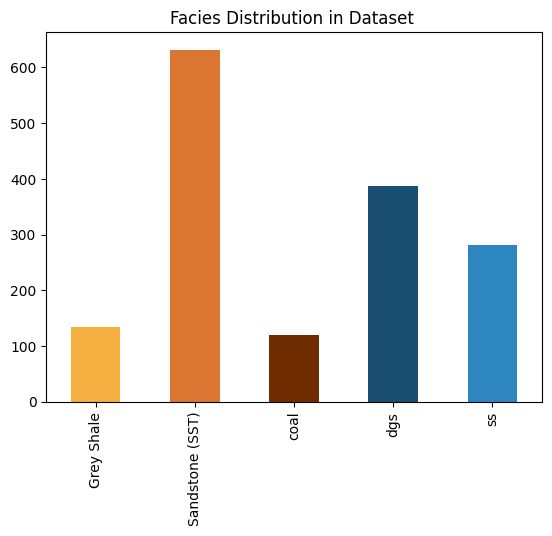

In [ ]:
import matplotlib.pyplot as plt
#count the number of unique entries for each facies, sort them by
#facies number (instead of by number of entries)
facies_counts = df['Classified'].value_counts().sort_index()
#use facies labels to index each count

# Step 1: Define new facies labels based on the unique values remaining in the filtered df
facies_labels = sorted(df['Classified'].unique())

# Step 2: Update facies_colors to match the new facies_labels
# Assuming you have enough colors defined in facies_colors list
# If not, you might need to adjust the number of colors
facies_colors = [ '#F5B041', '#DC7633', '#6E2C00',
                 '#1B4F72', '#2E86C1', '#AED6F1']

# Create a dictionary mapping facies labels to colors (ensure consistent order)
facies_color_map = {}
for ind, label in enumerate(facies_labels):
    facies_color_map[label] = facies_colors[ind]


facies_counts.index = facies_labels

facies_counts.plot(kind='bar',color=[facies_color_map[label] for label in facies_labels],
                   title='Facies Distribution in Dataset ')
#plt.savefig("F_Dist.png", dpi=300)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

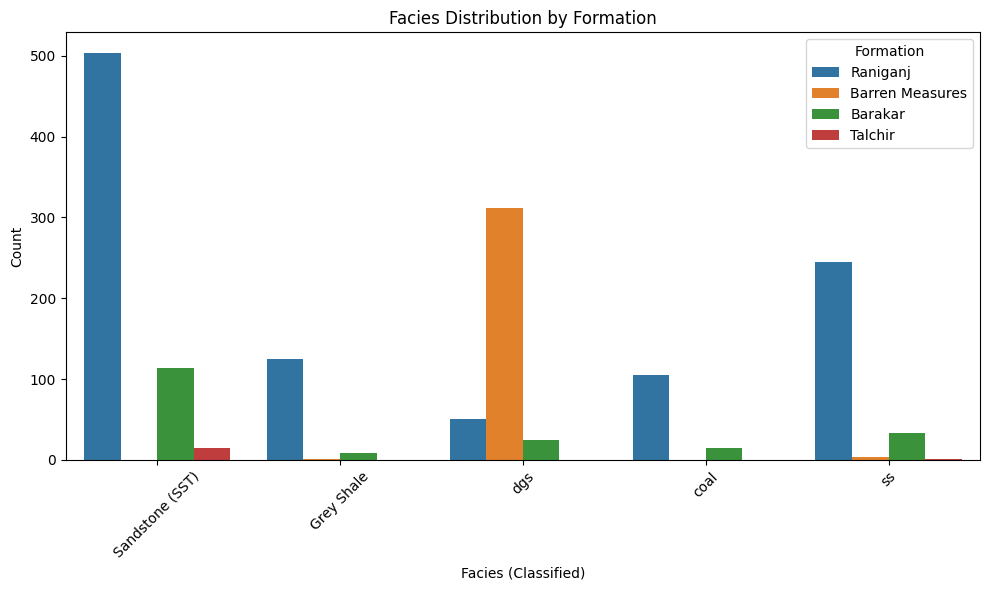

In [ ]:
# Plotting count of each facies (classified lithology) for every formation
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Classified', hue='Formation')
plt.xlabel('Facies (Classified)')
plt.ylabel('Count')
plt.title('Facies Distribution by Formation')
plt.xticks(rotation=45)
plt.legend(title='Formation')
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1555 entries, 4 to 1693
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DEPT[M]                1555 non-null   float64
 1   CALIPER[MM]            1555 non-null   float64
 2   DEN[GM/CC]             1555 non-null   float64
 3   RES(64N)               1555 non-null   float64
 4   RES[OHM]               1555 non-null   float64
 5   SP[MV]                 1555 non-null   float64
 6   GAM[API]               1555 non-null   float64
 7   LITHOLOGY DESCRIPTION  1555 non-null   object 
 8   Formation              1555 non-null   object 
 9   Classified             1555 non-null   object 
dtypes: float64(7), object(3)
memory usage: 133.6+ KB


In [ ]:
facies_counts


,count
Grey Shale,134
Sandstone (SST),632
coal,119
dgs,388
ss,282


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
columns_to_plot = ['CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]', 'SP[MV]', 'GAM[API]']

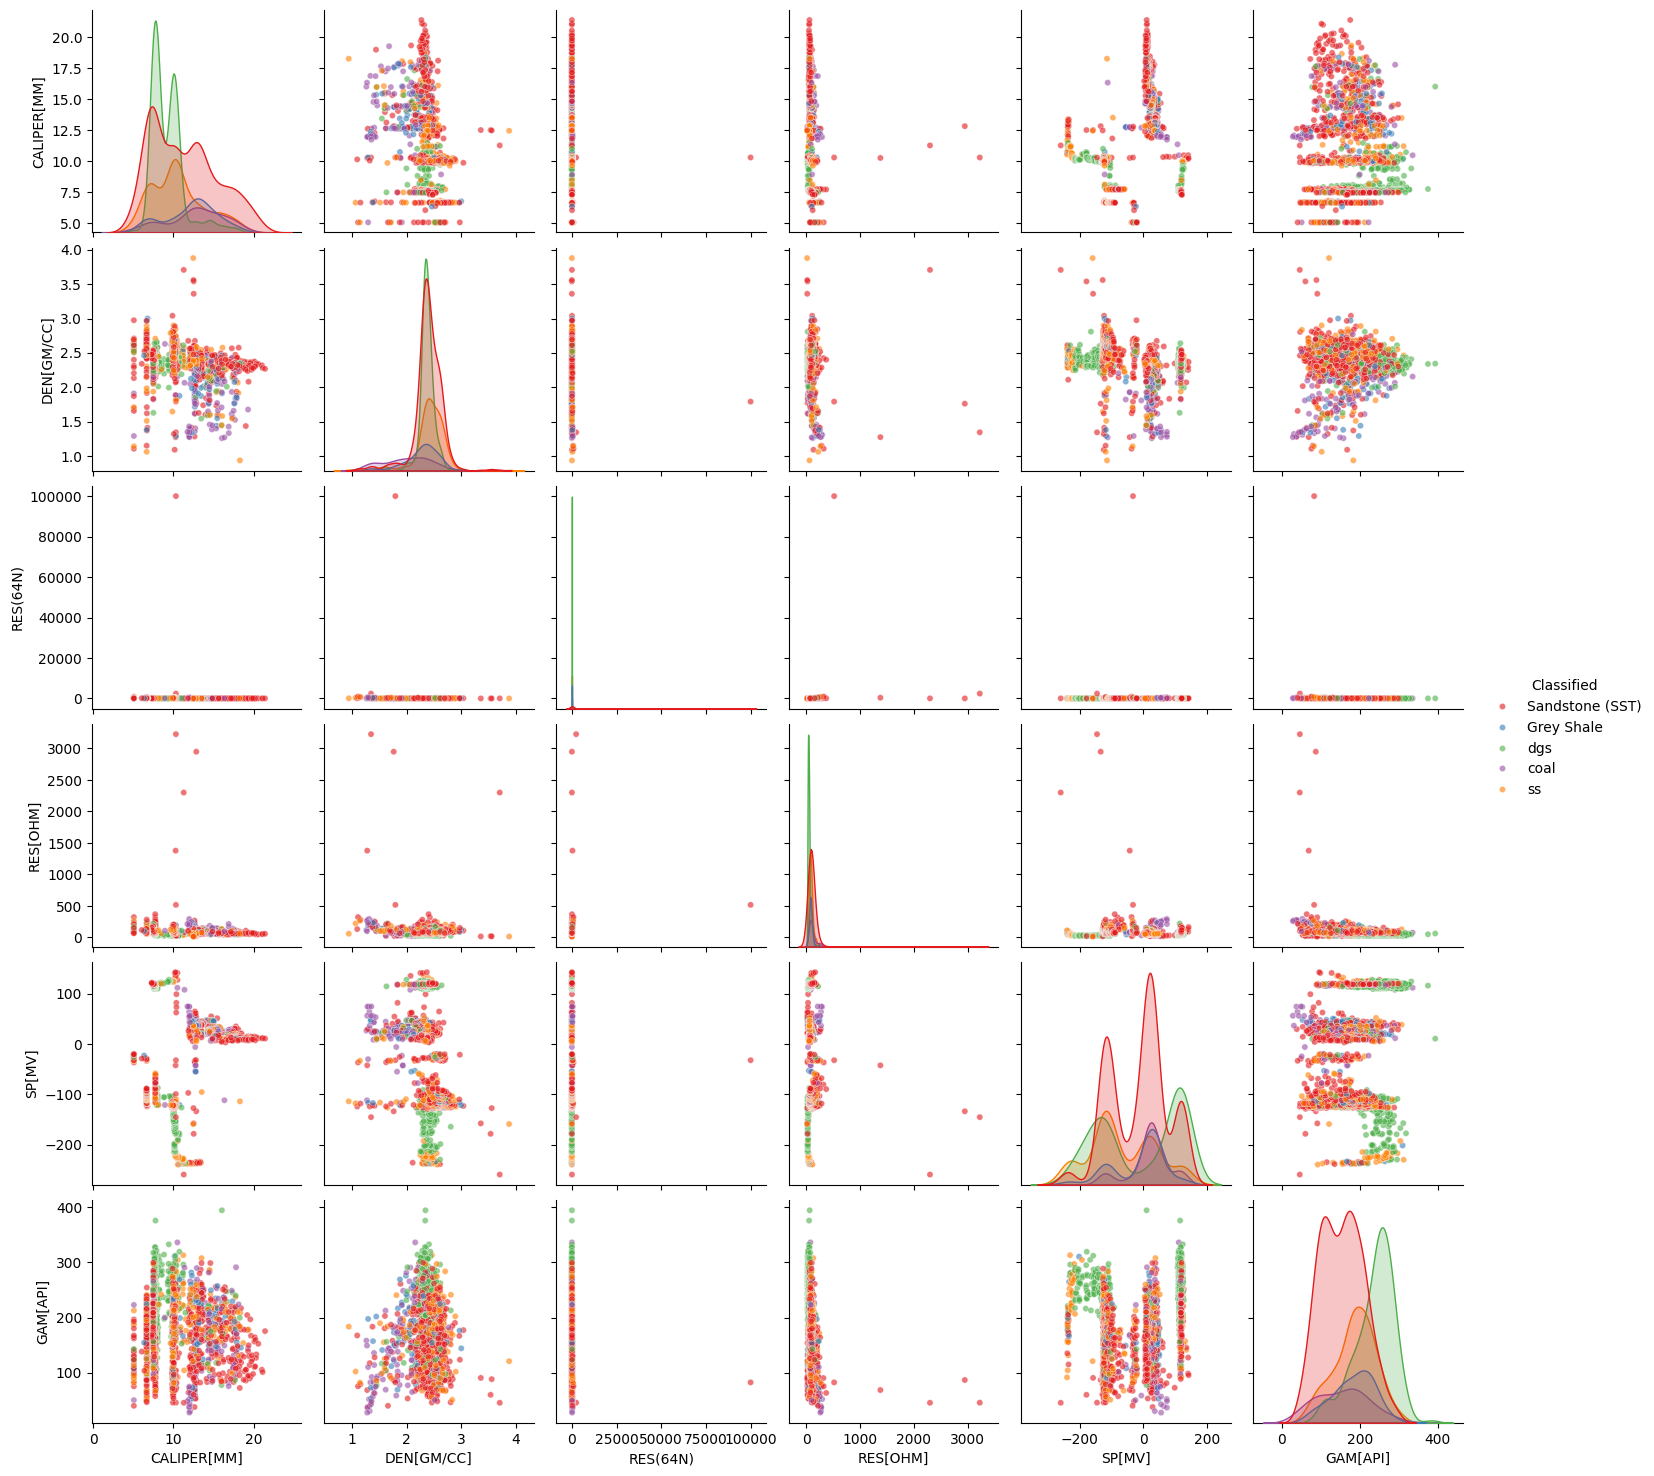

In [ ]:
sns.pairplot(
    df,
    vars=columns_to_plot,
    hue="Classified",
    palette="Set1",
    plot_kws={'alpha': 0.6, 's': 20}
)

plt.show()